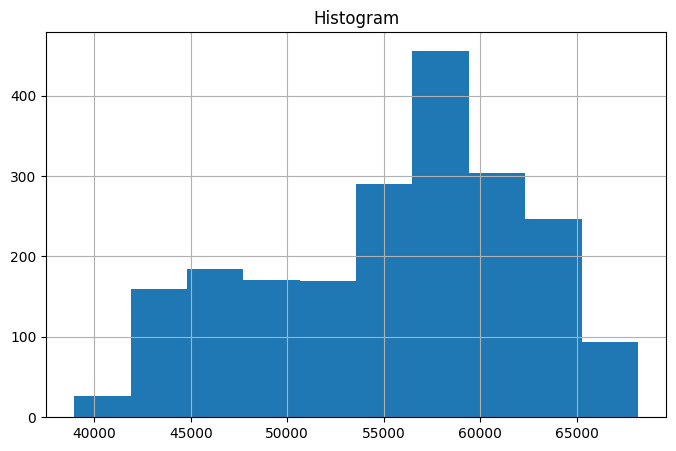

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

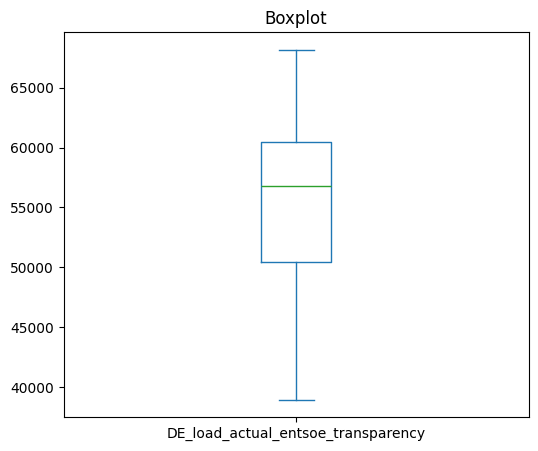

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

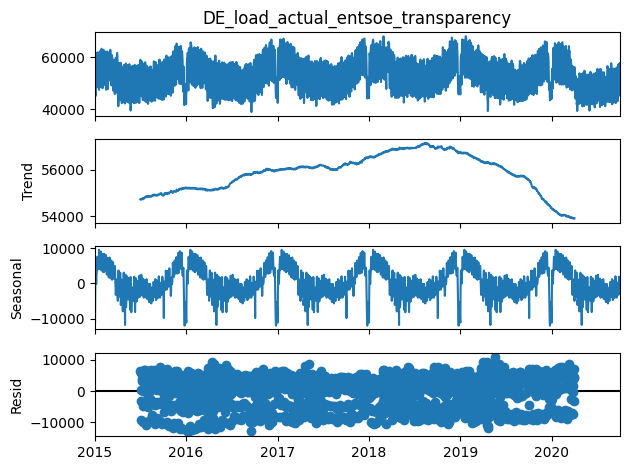

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

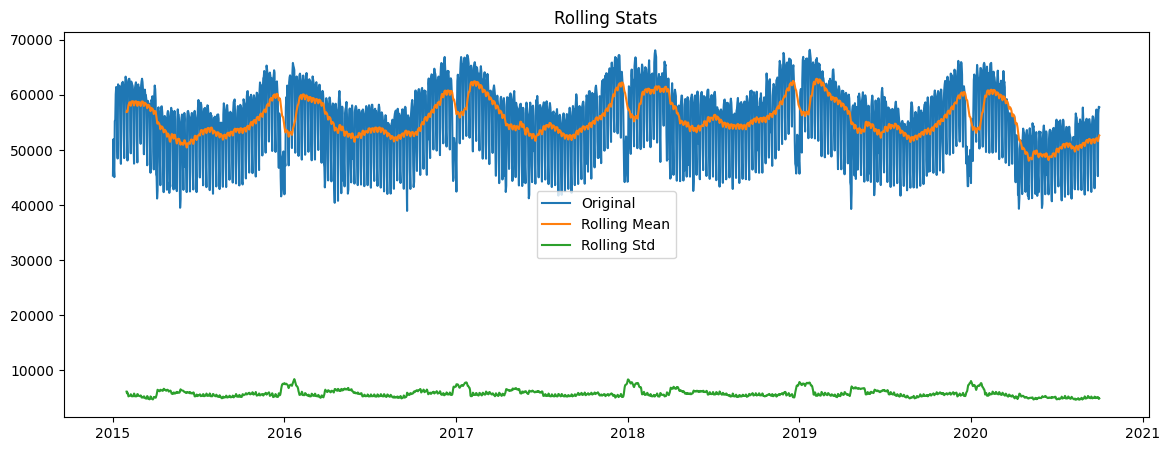

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

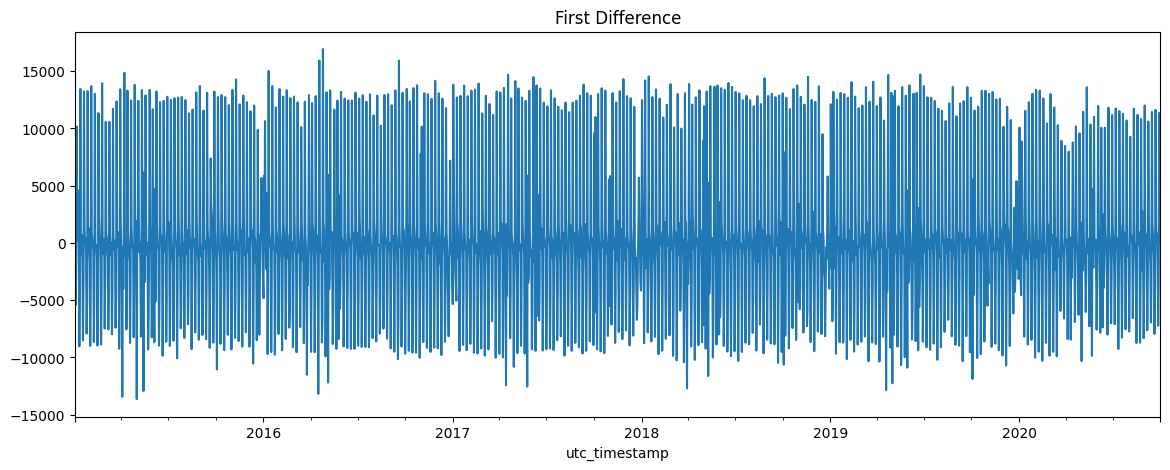

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

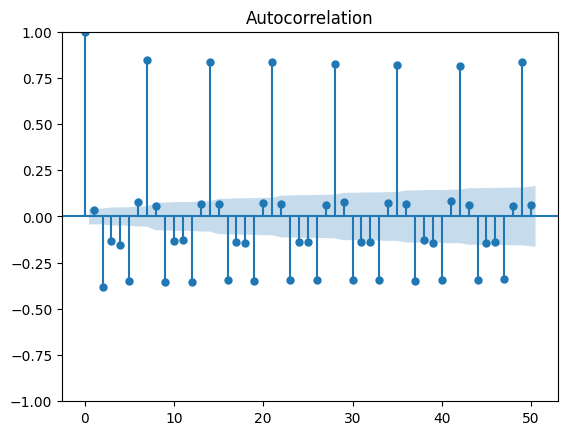

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

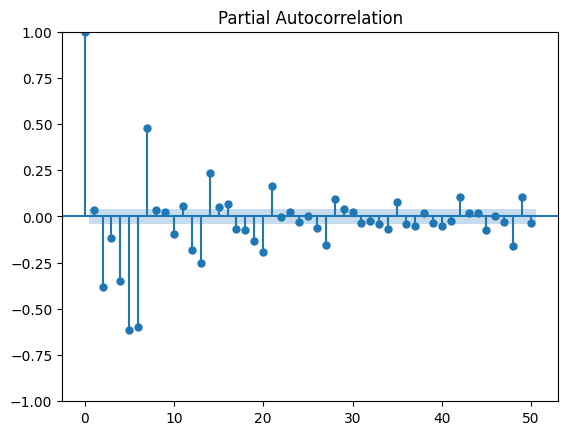

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import matplotlib.pyplot as plt
from google.colab import files
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --------------------
# 1. Histogram
# --------------------
daily.hist(figsize=(8,5))
plt.title("Histogram")
plt.savefig("histogram.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("histogram.png")

# --------------------
# 2. Boxplot
# --------------------
daily.plot(kind="box", figsize=(6,5))
plt.title("Boxplot")
plt.savefig("boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("boxplot.png")

# --------------------
# 3. Seasonal Decomposition
# --------------------
decomposition = seasonal_decompose(daily, model="additive", period=365)
fig = decomposition.plot()
fig.savefig("seasonal_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("seasonal_decomposition.png")

# --------------------
# 4. Rolling Mean & Std
# --------------------
rolling_mean = daily.rolling(window=30).mean()
rolling_std = daily.rolling(window=30).std()

plt.figure(figsize=(14,5))
plt.plot(daily, label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.title("Rolling Stats")
plt.savefig("rolling_stats.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("rolling_stats.png")

# --------------------
# 5. First Difference
# --------------------
diff = daily.diff().dropna()

plt.figure(figsize=(14,5))
diff.plot()
plt.title("First Difference")
plt.savefig("first_difference.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("first_difference.png")

# --------------------
# 6. ACF
# --------------------
plot_acf(diff, lags=50)
plt.savefig("acf.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("acf.png")

# --------------------
# 7. PACF
# --------------------
plot_pacf(diff, lags=50)
plt.savefig("pacf.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("pacf.png")

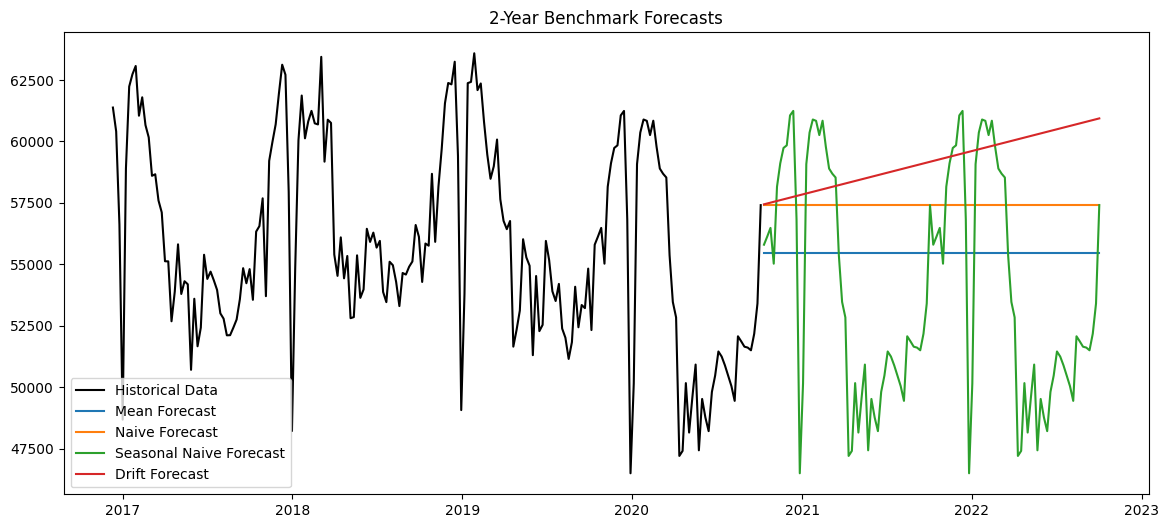

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# Prepare weekly data
# -----------------------------
ts = df["DE_load_actual_entsoe_transparency"].dropna()
weekly = ts.resample("W").mean()

train = weekly

# Forecast horizon = 2 years weekly
h = 52 * 2

# Create future index
last_date = weekly.index[-1]
future_index = pd.date_range(start=last_date, periods=h+1, freq="W")[1:]

# -----------------------------
# 1. Mean Forecast
# -----------------------------
mean_forecast = pd.Series(train.mean(), index=future_index)

# -----------------------------
# 2. Naive Forecast
# -----------------------------
naive_forecast = pd.Series(train.iloc[-1], index=future_index)

# -----------------------------
# 3. Seasonal Naive
# -----------------------------
season_length = 52
seasonal_naive_forecast = pd.Series(
    [train.iloc[-season_length + (i % season_length)] for i in range(h)],
    index=future_index
)

# -----------------------------
# 4. Drift Forecast
# -----------------------------
n = len(train)
drift = (train.iloc[-1] - train.iloc[0]) / (n - 1)

drift_forecast = pd.Series(
    [train.iloc[-1] + (i + 1) * drift for i in range(h)],
    index=future_index
)

# -----------------------------
# Plot all forecasts
# -----------------------------
plt.figure(figsize=(14,6))

plt.plot(train[-200:], label="Historical Data", color="black")
plt.plot(mean_forecast, label="Mean Forecast")
plt.plot(naive_forecast, label="Naive Forecast")
plt.plot(seasonal_naive_forecast, label="Seasonal Naive Forecast")
plt.plot(drift_forecast, label="Drift Forecast")

plt.title("2-Year Benchmark Forecasts")
plt.legend()

# -----------------------------
# SAVE IMAGE
# -----------------------------
filename = "benchmark_forecast.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")

plt.show()

# -----------------------------
# DOWNLOAD IMAGE (Colab)
# -----------------------------
files.download(filename)

In [8]:
#part 3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error
import itertools
import warnings
warnings.filterwarnings("ignore")

In [9]:
#part 3
ts = df["DE_load_actual_entsoe_transparency"].dropna()
weekly = ts.resample("W").mean()

In [10]:
#part 3
h = 52 * 2  # 2 years

train = weekly[:-h]
test = weekly[-h:]

In [11]:
#Part 3
p = d = q = range(0, 3)   # safer subset (you can expand to 6 if PC allows)
P = D = Q = range(0, 2)
seasonal_period = 52

best_aic = np.inf
best_order = None
best_seasonal = None
best_model = None

for order in itertools.product(p, d, q):
    for seasonal in itertools.product(P, D, Q):
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=(seasonal[0], seasonal[1], seasonal[2], seasonal_period),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal = seasonal
                best_model = results

        except:
            continue

print("Best SARIMA order:", best_order)
print("Best seasonal order:", best_seasonal)
print("Best AIC:", best_aic)

Best SARIMA order: (2, 0, 1)
Best seasonal order: (1, 0, 1)
Best AIC: 903.9704168436691


In [12]:
#part 3
residuals = best_model.resid

<Figure size 1000x400 with 0 Axes>

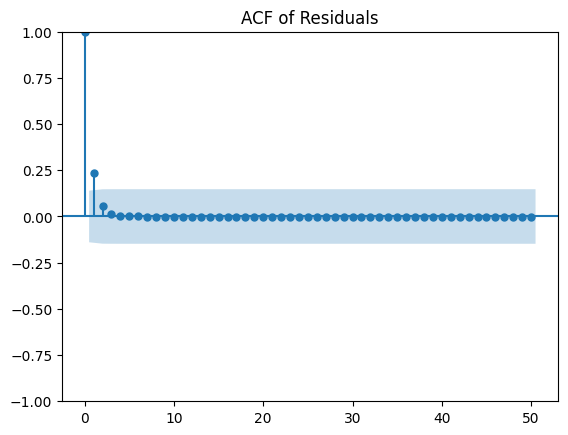

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
#part 3
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from google.colab import files

plt.figure(figsize=(10,4))

plot_acf(residuals.dropna(), lags=50)
plt.title("ACF of Residuals")

# --------------------
# SAVE FIGURE
# --------------------
filename = "acf_residuals.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")

plt.show()

# --------------------
# DOWNLOAD (Colab)
# --------------------
files.download(filename)

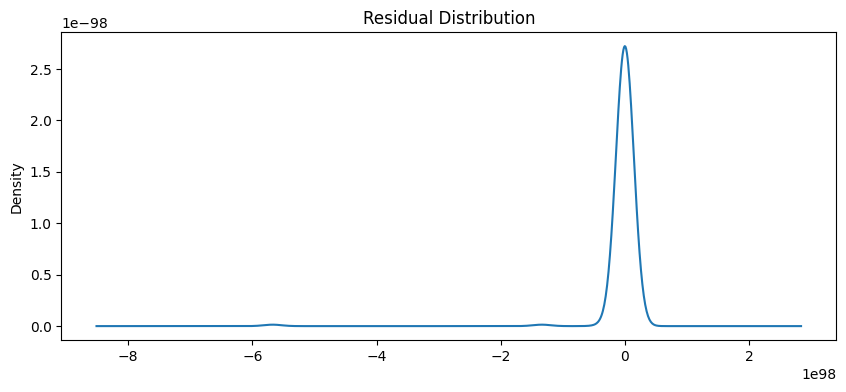

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
#part 3
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(10,4))

residuals.plot(kind="kde")

plt.title("Residual Distribution")

# --------------------
# SAVE IMAGE
# --------------------
filename = "residual_kde.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")

plt.show()

# --------------------
# DOWNLOAD (Colab)
# --------------------
files.download(filename)

In [15]:
#part 3
forecast = best_model.get_forecast(steps=h)

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

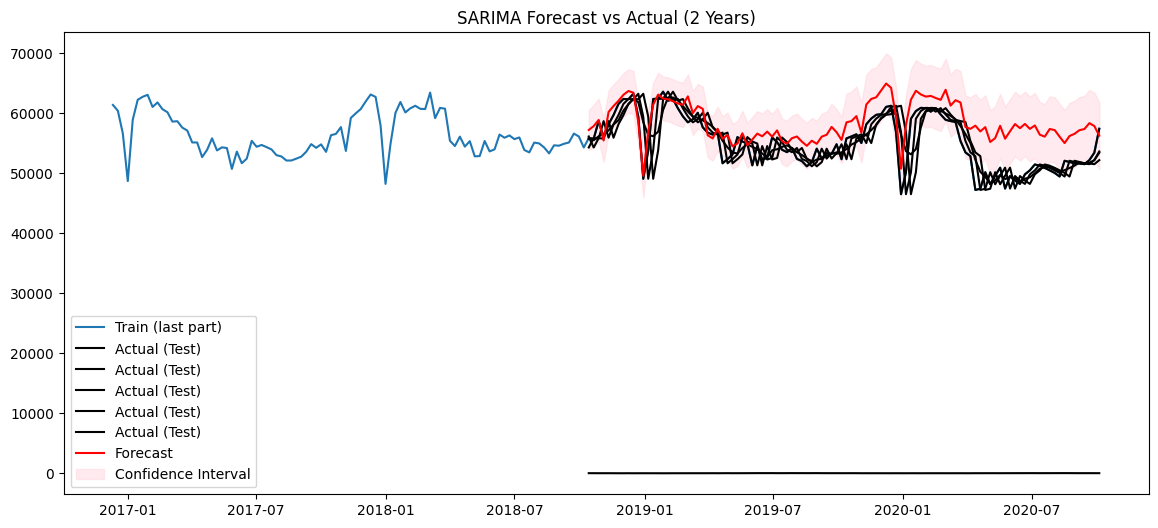

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
#part 3
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(14,6))

plt.plot(train[-200:], label="Train (last part)")
plt.plot(test, label="Actual (Test)", color="black")

plt.plot(test.index, forecast_mean, label="Forecast", color="red")

plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual (2 Years)")
plt.legend()

# --------------------
# SAVE IMAGE
# --------------------
filename = "sarima_forecast.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")

plt.show()

# --------------------
# DOWNLOAD (Colab)
# --------------------
files.download(filename)

In [17]:
#part 3
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
print("RMSE:", rmse)

RMSE: inf


RMSE = 4232.3043902956915


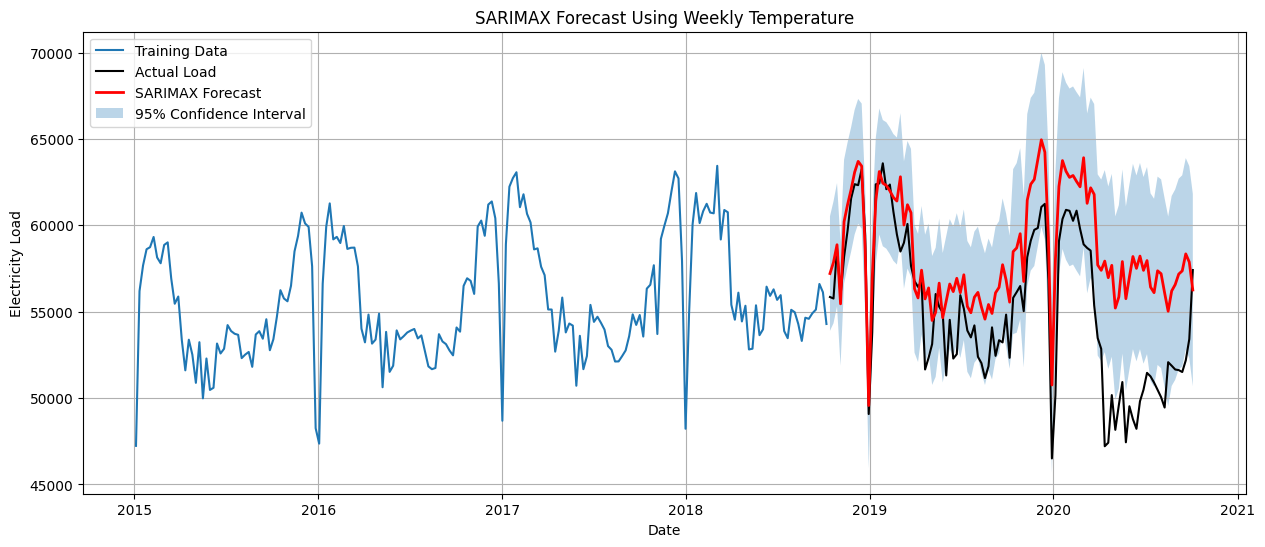

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from google.colab import files

# =====================================================
# LOAD ELECTRICITY DATA
# =====================================================
df = pd.read_csv("/content/time_series_60min_singleindex.csv")

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
df["utc_timestamp"] = df["utc_timestamp"].dt.tz_localize(None)
df.set_index("utc_timestamp", inplace=True)

weekly_load = (
    df["DE_load_actual_entsoe_transparency"]
    .dropna()
    .resample("W")
    .mean()
)

# =====================================================
# LOAD BERLIN TEMPERATURE JSON
# =====================================================
temp_json = pd.read_json("/content/berlin_temperature.csv.json")

temp = pd.DataFrame({
    "date": pd.to_datetime(temp_json["daily"]["time"]),
    "temperature": temp_json["daily"]["temperature_2m_mean"]
})

temp.set_index("date", inplace=True)

weekly_temp = temp.resample("W").mean()

# =====================================================
# MERGE DATASETS
# =====================================================
data = pd.concat([weekly_load, weekly_temp], axis=1)
data.columns = ["load", "temperature"]
data = data.dropna()

# =====================================================
# TRAIN / TEST SPLIT
# =====================================================
h = 104   # 2 years

train = data[:-h]
test = data[-h:]

# =====================================================
# SARIMAX MODEL
# =====================================================
model = SARIMAX(
    train["load"],
    exog=train[["temperature"]],
    order=(1,1,1),
    seasonal_order=(1,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# =====================================================
# FORECAST
# =====================================================
forecast = results.get_forecast(
    steps=h,
    exog=test[["temperature"]]
)

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# =====================================================
# RMSE
# =====================================================
rmse = np.sqrt(mean_squared_error(test["load"], forecast_mean))
print("RMSE =", rmse)

# =====================================================
# PLOT + SAVE
# =====================================================
plt.figure(figsize=(15,6))

plt.plot(train.index, train["load"], label="Training Data")
plt.plot(test.index, test["load"], label="Actual Load", color="black")

plt.plot(test.index, forecast_mean,
         color="red",
         linewidth=2,
         label="SARIMAX Forecast")

plt.fill_between(
    test.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMAX Forecast Using Weekly Temperature")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(True)

# --------------------
# SAVE IMAGE
# --------------------
filename = "sarimax_forecast.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")

plt.show()

# --------------------
# DOWNLOAD IMAGE (Colab)
# --------------------
files.download(filename)

RMSE: 2111.678885182966


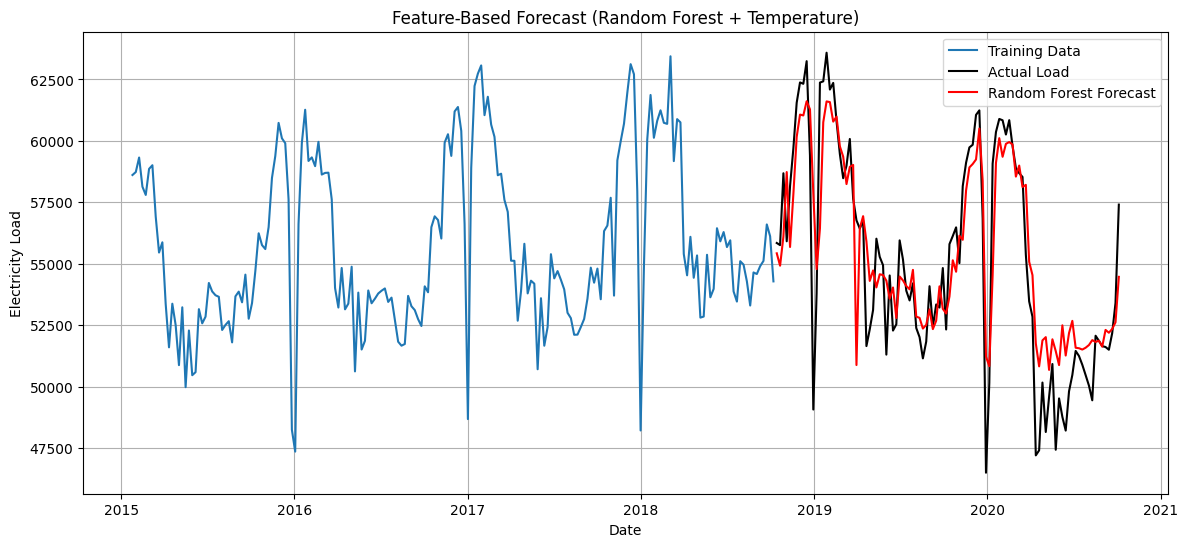

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
#part 5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from google.colab import files

# =====================================================
# 1. LOAD ELECTRICITY DATA
# =====================================================
df = pd.read_csv("/content/time_series_60min_singleindex.csv")

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
df["utc_timestamp"] = df["utc_timestamp"].dt.tz_localize(None)
df.set_index("utc_timestamp", inplace=True)

weekly_load = df["DE_load_actual_entsoe_transparency"].resample("W").mean()

# =====================================================
# 2. LOAD BERLIN TEMPERATURE
# =====================================================
temp_json = pd.read_json("/content/berlin_temperature.csv.json")

temp = pd.DataFrame({
    "date": pd.to_datetime(temp_json["daily"]["time"]),
    "temperature": temp_json["daily"]["temperature_2m_mean"]
})

temp.set_index("date", inplace=True)

weekly_temp = temp.resample("W").mean()

# =====================================================
# 3. MERGE DATA
# =====================================================
data = pd.concat([weekly_load, weekly_temp], axis=1)
data.columns = ["load", "temperature"]
data = data.dropna()

# =====================================================
# 4. FEATURE ENGINEERING
# =====================================================
data["lag1"] = data["load"].shift(1)
data["lag2"] = data["load"].shift(2)
data["rolling_mean_4"] = data["load"].rolling(4).mean()

data = data.dropna()

# =====================================================
# 5. TRAIN / TEST SPLIT
# =====================================================
h = 104  # 2 years

train = data[:-h]
test = data[-h:]

X_train = train[["temperature", "lag1", "lag2", "rolling_mean_4"]]
y_train = train["load"]

X_test = test[["temperature", "lag1", "lag2", "rolling_mean_4"]]
y_test = test["load"]

# =====================================================
# 6. RANDOM FOREST MODEL
# =====================================================
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 7. PREDICTION
# =====================================================
pred = model.predict(X_test)

# =====================================================
# 8. RMSE
# =====================================================
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

# =====================================================
# 9. PLOT + SAVE
# =====================================================
plt.figure(figsize=(14,6))

plt.plot(train.index, train["load"], label="Training Data")
plt.plot(test.index, y_test, label="Actual Load", color="black")
plt.plot(test.index, pred, label="Random Forest Forecast", color="red")

plt.title("Feature-Based Forecast (Random Forest + Temperature)")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(True)

# --------------------
# SAVE IMAGE
# --------------------
filename = "random_forest_forecast.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")

plt.show()

# --------------------
# DOWNLOAD IMAGE
# --------------------
files.download(filename)

Epoch 1/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 66s 119ms/step - loss: 0.0189 - val_loss: 0.0048
Epoch 2/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 55s 107ms/step - loss: 0.0053 - val_loss: 0.0030
Epoch 3/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 56s 109ms/step - loss: 0.0036 - val_loss: 0.0023
Epoch 4/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 57s 111ms/step - loss: 0.0029 - val_loss: 0.0016
Epoch 5/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 6/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 56s 108ms/step - loss: 0.0022 - val_loss: 0.0013
Epoch 7/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 55s 108ms/step - loss: 0.0019 - val_loss: 9.4954e-04
Epoch 8/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - loss: 0.0018 - val_loss: 8.7875e-04
Epoch 9/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - loss: 0.0016 - val_loss: 7.2897e-04
Epoch 10/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 80s 103ms/step - loss: 0.0015 - val_loss: 9.9320e-04
548/548 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step
RMSE: 1457.317446485233
MAE: 1142.512564100849


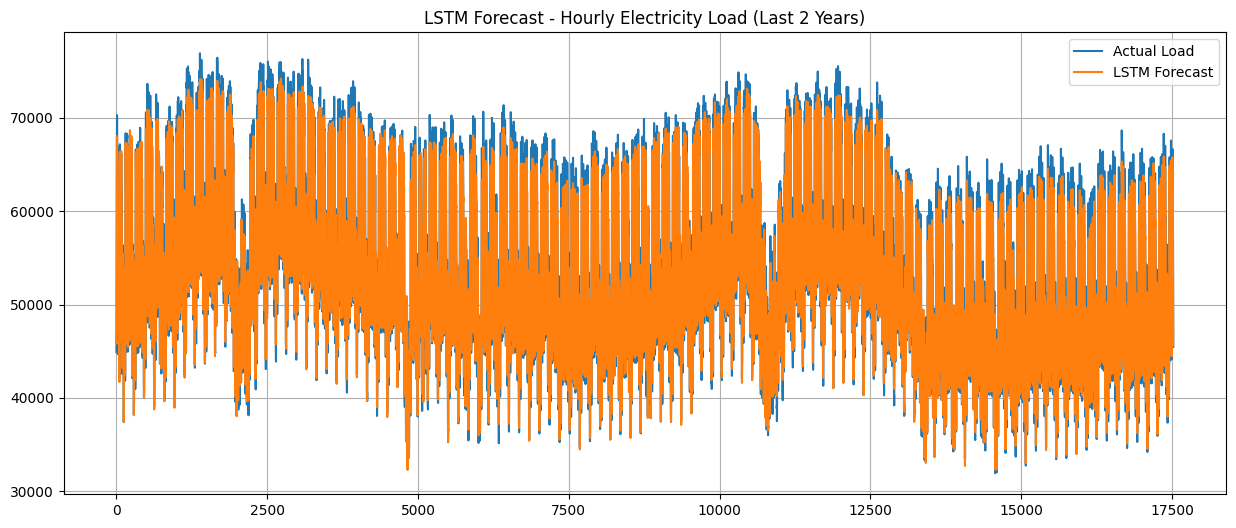

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from google.colab import files

# =====================================================
# 1. LOAD HOURLY DATA
# =====================================================
df = pd.read_csv("/content/time_series_60min_singleindex.csv")

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
df["utc_timestamp"] = df["utc_timestamp"].dt.tz_localize(None)
df.set_index("utc_timestamp", inplace=True)

ts = df["DE_load_actual_entsoe_transparency"].dropna()

hourly = ts.resample("H").mean().ffill()

# =====================================================
# 2. SCALE DATA
# =====================================================
scaler = MinMaxScaler()
scaled = scaler.fit_transform(hourly.values.reshape(-1, 1))

# =====================================================
# 3. CREATE SEQUENCES
# =====================================================
time_step = 48

X, y = [], []

for i in range(len(scaled) - time_step):
    X.append(scaled[i:i+time_step])
    y.append(scaled[i+time_step])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

# =====================================================
# 4. TRAIN / TEST SPLIT
# =====================================================
h = 24 * 365 * 2  # 2 years hourly

train_size = len(X) - h

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# =====================================================
# 5. LSTM MODEL
# =====================================================
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))

model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

# =====================================================
# 6. TRAIN MODEL
# =====================================================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# =====================================================
# 7. PREDICTION
# =====================================================
pred = model.predict(X_test)

pred_inv = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test)

# =====================================================
# 8. METRICS
# =====================================================
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))
mae = mean_absolute_error(y_test_inv, pred_inv)

print("RMSE:", rmse)
print("MAE:", mae)

# =====================================================
# 9. PLOT + SAVE
# =====================================================
plt.figure(figsize=(15,6))

plt.plot(y_test_inv, label="Actual Load")
plt.plot(pred_inv, label="LSTM Forecast")

plt.title("LSTM Forecast - Hourly Electricity Load (Last 2 Years)")
plt.legend()
plt.grid(True)

# --------------------
# SAVE IMAGE
# --------------------
filename = "lstm_forecast.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")

plt.show()

# --------------------
# DOWNLOAD IMAGE
# --------------------
files.download(filename)